# Check for Radiation artefacts in Irenes Exeriments

### Martin Stengel found some weird artifacts in ICON radiation fluxes:
- Some 2d_rad_DOM01_* files show small holes in the radiation fluxes, especially in cloudy cases (in the september case)
- this notebook checks if those artefacts can also be seen in Experiments run by Irene (descriprion of experiments see https://gitlab.dkrz.de/c3sar-tropos/c3sar-experiments/-/blob/main/README.md?ref_type=heads)
- suitable experiments:
  - exp.cesar1-20240806-exp003
  - 


In [1]:
%matplotlib inline

# system libs
import os, sys, glob
import datetime

# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# plotting
import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

import warnings
warnings.simplefilter("ignore")

## Open datasets, cut domain and format time

In [2]:
# Path
# Irenes experiment:
sim_path = '/work/bb1376/user/irene/icon-build/experiments/cesar1-20240806-exp003'



In [3]:
# ICON simulations for 3 nests:
# 2D variables
#ds_2dicon1 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon1 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon2 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM02_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon3 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM03_ML_20240806T????00Z_regrid1km.nc')

# 3D variables
ds_3dicon1 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_3dicon2 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM02_ML_20240806T????00Z_regrid1km.nc')
ds_3dicon3 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM03_ML_20240806T????00Z_regrid1km.nc')


In [4]:
#radiation varibles.
ds_2dicon1rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon2rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM02_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon3rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM03_ML_20240806T????00Z_regrid1km.nc')

In [5]:
# Define dictionaries to store datasets
datasets2d = {
    "exp001 icon d1": ds_2dicon1,
    "exp001 icon d2": ds_2dicon2,
    "exp001 icon d3": ds_2dicon3,
}

datasets2drad = {
    "exp001 icon d1 rad": ds_2dicon1rad,
    "exp001 icon d2 rad": ds_2dicon2rad,
    "exp001 icon d3 rad": ds_2dicon3rad,
}



datasets3d = {
    "exp001 icon d1": ds_3dicon1,
    "exp001 icon d2": ds_3dicon2,
    "exp001 icon d3": ds_3dicon3,
}

In [6]:
# Define Lindenberg coordinates:
lon_lind, lat_lind = 14.11845, 52.20967

# Define the spatial range over Lindenberg:
lat_min, lat_max = 51.85, 52.55    
lon_min, lon_max = 13.65, 14.55 

# Apply spatial selection to all datasets
for datasets in [datasets2d, datasets3d]:
    for name, ds in datasets.items():
        datasets[name] = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))


In [7]:
# Format time 
for name, ds in datasets2d.items():
    ds['time'] = convert_timevec(ds.time.data)
for name, ds in datasets3d.items():
    ds['time'] = convert_timevec(ds.time.data)

## Analysis


In [8]:
ds_2dicon1

<xarray.Dataset>
Dimensions:        (time: 49, lon: 801, lat: 501, plev: 1, bnds: 2, plev_2: 1,
                    plev_3: 1, height: 151, height_2: 1, depth: 8, depth_2: 9,
                    depth_3: 1)
Coordinates:
  * time           (time) float64 2.024e+07 2.024e+07 ... 2.024e+07 2.024e+07
  * lon            (lon) float64 10.0 10.01 10.02 10.03 ... 17.98 17.99 18.0
  * lat            (lat) float64 50.0 50.01 50.02 50.03 ... 54.98 54.99 55.0
  * plev           (plev) float64 0.0
  * plev_2         (plev_2) float64 400.0
  * plev_3         (plev_3) float64 800.0
  * height         (height) float64 1.0 2.0 3.0 4.0 ... 148.0 149.0 150.0 151.0
  * height_2       (height_2) float64 10.0
  * depth          (depth) float64 5.0 20.0 60.0 ... 1.62e+03 4.86e+03 1.458e+04
  * depth_2        (depth_2) float64 0.0 5.0 20.0 ... 4.86e+03 1.458e+04
  * depth_3        (depth_3) float64 0.0
Dimensions without coordinates: bnds
Data variables: (12/52)
    plev_bnds      (time, plev, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    plev_2_bnds    (time, plev_2, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    plev_3_bnds    (time, plev_3, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    tqv_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    tqc_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    tqi_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    ...             ...
    sobclr_s       (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    thbclr_s       (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    lwflx_dn_clr   (time, height, lat, lon) float32 dask.array<chunksize=(12, 151, 501, 801), meta=np.ndarray>
    lwflx_up_clr   (time, height, lat, lon) float32 dask.array<chunksize=(12, 151, 501, 801), meta=np.ndarray>
    swflx_dn_clr   (time, height, lat, lon) float32 dask.array<chunksize=(12, 151, 501, 801), meta=np.ndarray>
    swflx_up_clr   (time, height, lat, lon) float32 dask.array<chunksize=(12, 151, 501, 801), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    source:       version: 2024.10; revision: icon-2024.10-public-0-ga1324166...
    history:      /home/b/b383134/workspace/icon-build/bin/icon at 20250331 1...
    references:   see MPIM/DWD publications
    comment:      Irene Bellagente (b383134) on l40682 (Linux 4.18.0-513.24.1...

## Define plots and choose timestamps 

In [9]:
def plot_map(datasets, variable, time_point, title, colorbar_label, dim_mean=None, vmin=None, vmax=None):
    """
    Create a set of subplots with a specified variable from different datasets.
    
    Parameters:
    - datasets: Dictionary of datasets, where the key is the dataset name and the value is the dataset.
    - variable: The variable in the dataset to plot (e.g., 'clct').
    - time_point: The specific time point to select from the dataset (e.g., '2024-08-06T13:00:00.000000000').
    - title: Title for the entire plot.
    - colorbar_label: Label for the colorbar.
    - dim_mean: (Optional) Dimension to apply mean operation if using 3D datasets (e.g., 'time').
    - vmin, vmax: Minimum value for color scale, Maximum value for color scale.
    """
    
    # Create subplots with PlateCarree projection
    fig, axes = plt.subplots(1, len(datasets), figsize=(15, 4), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.3})

    for ax, (name, ds) in zip(axes, datasets.items()):
        # Check if the dataset is 3D
        if dim_mean and len(ds[variable].dims) > 2:  # Assuming 3D means more than 2 dimensions
            data = ds[variable].sel(time=time_point).mean(dim=dim_mean)
        else:
            data = ds[variable].sel(time=time_point)
        
        # Plot with specified vmin and vmax
        data.plot(ax=ax, add_colorbar=False, vmin=vmin, vmax=vmax)
        
        ax.set_title(name)
        ax.coastlines()
        ax.plot(14.11845, 52.20967, marker='x', color='red', markersize=8)  # Mark the specified position
        
        # Add gridlines with labels
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0)
        gl.top_labels, gl.right_labels = False, False  # Disable top and right labels
        gl.xlabel_style, gl.ylabel_style = {'size': 11}, {'size': 11}

    # Add a single colorbar
    cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(colorbar_label)

    # Add a title and adjust layout
    plt.suptitle(title, fontsize=16)
    plt.show()


### New Function to plot differernt timepoints in different rows:

In [10]:
def plot_map_multiple_times(datasets, variable, time_points, title, colorbar_label, dim_mean=None, vmin=None, vmax=None):
    """
    Create a grid of subplots for a variable at multiple time points and across multiple datasets.

    Parameters:
    - datasets: dict of xarray datasets
    - variable: variable to plot
    - date: str
    - title: str, overall title
    - colorbar_label: str, label for colorbar
    - dim_mean: optional, dimension to reduce with mean (e.g., 'time')
    - vmin, vmax: optional, color scale limits
    """


    # Set up the grid of subplots (rows: time points, columns: datasets)
    fig, axes = plt.subplots(
        len(time_points), len(datasets),
        figsize=(5 * len(datasets), 3.5 * len(time_points)),
        subplot_kw={'projection': ccrs.PlateCarree()},
        squeeze=False
    )

    for row_idx, time_point in enumerate(time_points):
        for col_idx, (name, ds) in enumerate(datasets.items()):
            ax = axes[row_idx, col_idx]
            try:
                if dim_mean and len(ds[variable].dims) > 2:
                    data = ds[variable].sel(time=time_point).mean(dim=dim_mean)
                else:
                    data = ds[variable].sel(time=time_point)

                img = data.plot(ax=ax, add_colorbar=False, vmin=vmin, vmax=vmax)
                #img = data.plot(ax=ax, add_colorbar=True, vmin=vmin, vmax=vmax)
                ax.coastlines()
                ax.plot(14.11845, 52.20967, marker='x', color='red', markersize=6)
                ax.set_title(name if row_idx == 0 else "")
                
                gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0)
                gl.top_labels, gl.right_labels = False, False
                gl.left_labels = col_idx == 0
                gl.bottom_labels = row_idx == len(time_points) - 1
                gl.xlabel_style, gl.ylabel_style = {'size': 10}, {'size': 10}

                # Label the row (time) on the leftmost axis
                if col_idx == 0:
                    ax.text(-0.2, 0.5, time_point[:16], va='center', ha='right',
                            transform=ax.transAxes, fontsize=15, rotation=90)
            except Exception as e:
                ax.set_title(f"{name} - ERROR")
                ax.text(0.5, 0.5, time_point[-8:], transform=ax.transAxes, ha='center', va='center')

    # Add a single colorbar
    cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(colorbar_label)

    plt.suptitle(title, fontsize=18)
    #plt.tight_layout(rect=[0, 0, 0.95, 0.96])
    plt.show()


In [11]:
#time_points = [ '2024-08-06T08:00:00.000000000','2024-08-06T12:00:00.000000000','2024-08-06T18:00:00.000000000']
time_points = [ '2024-08-06T13:00:00.000000000','2024-08-06T14:00:00.000000000','2024-08-06T16:00:00.000000000']

## Radiative variables TOA

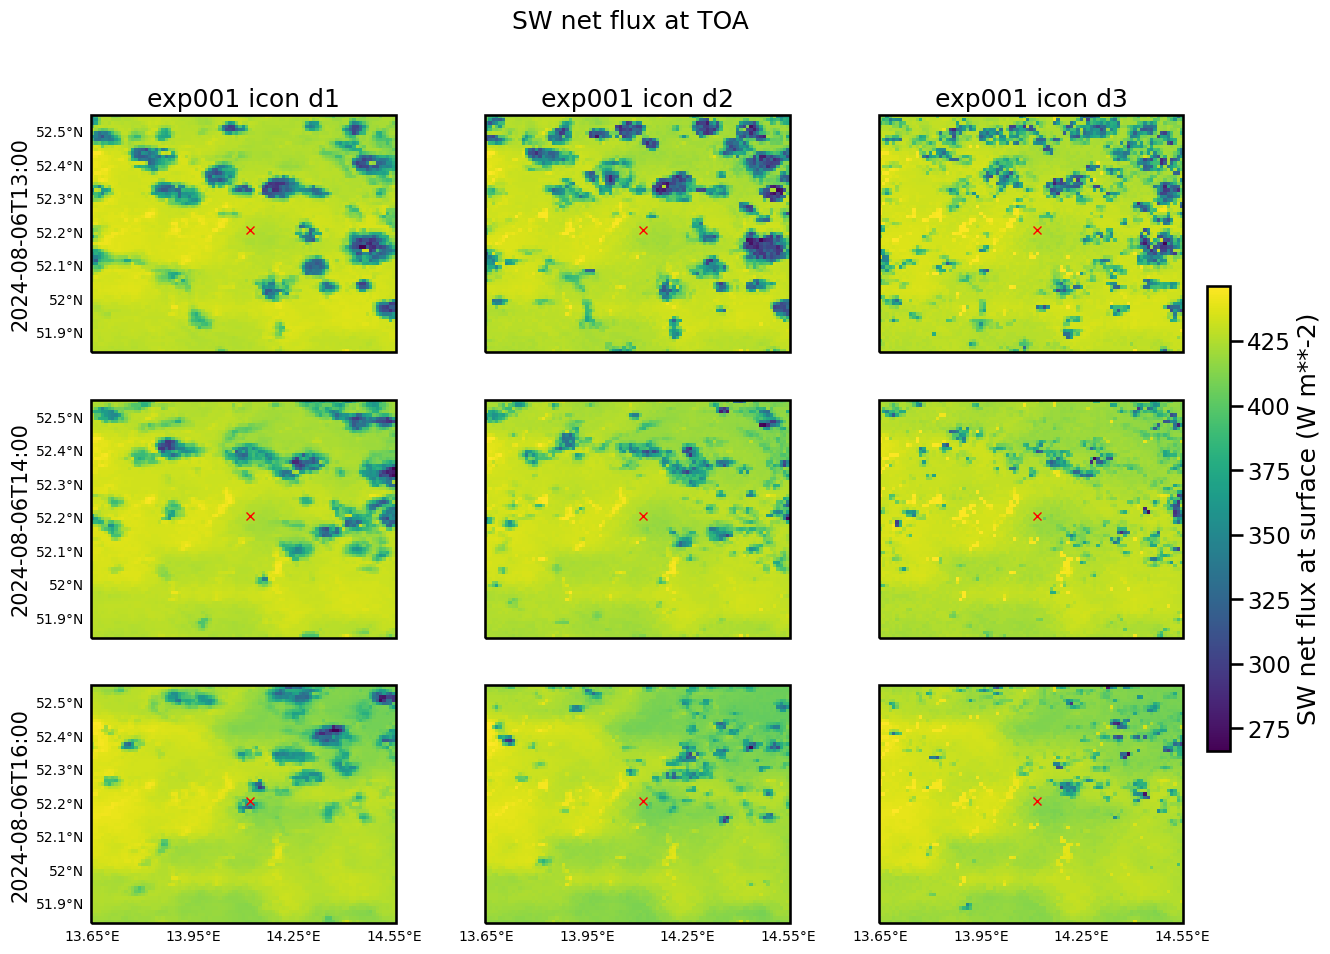

In [12]:
plot_map_multiple_times(datasets2d,'sob_t',time_points,"SW net flux at TOA","SW net flux at surface (W m**-2)")

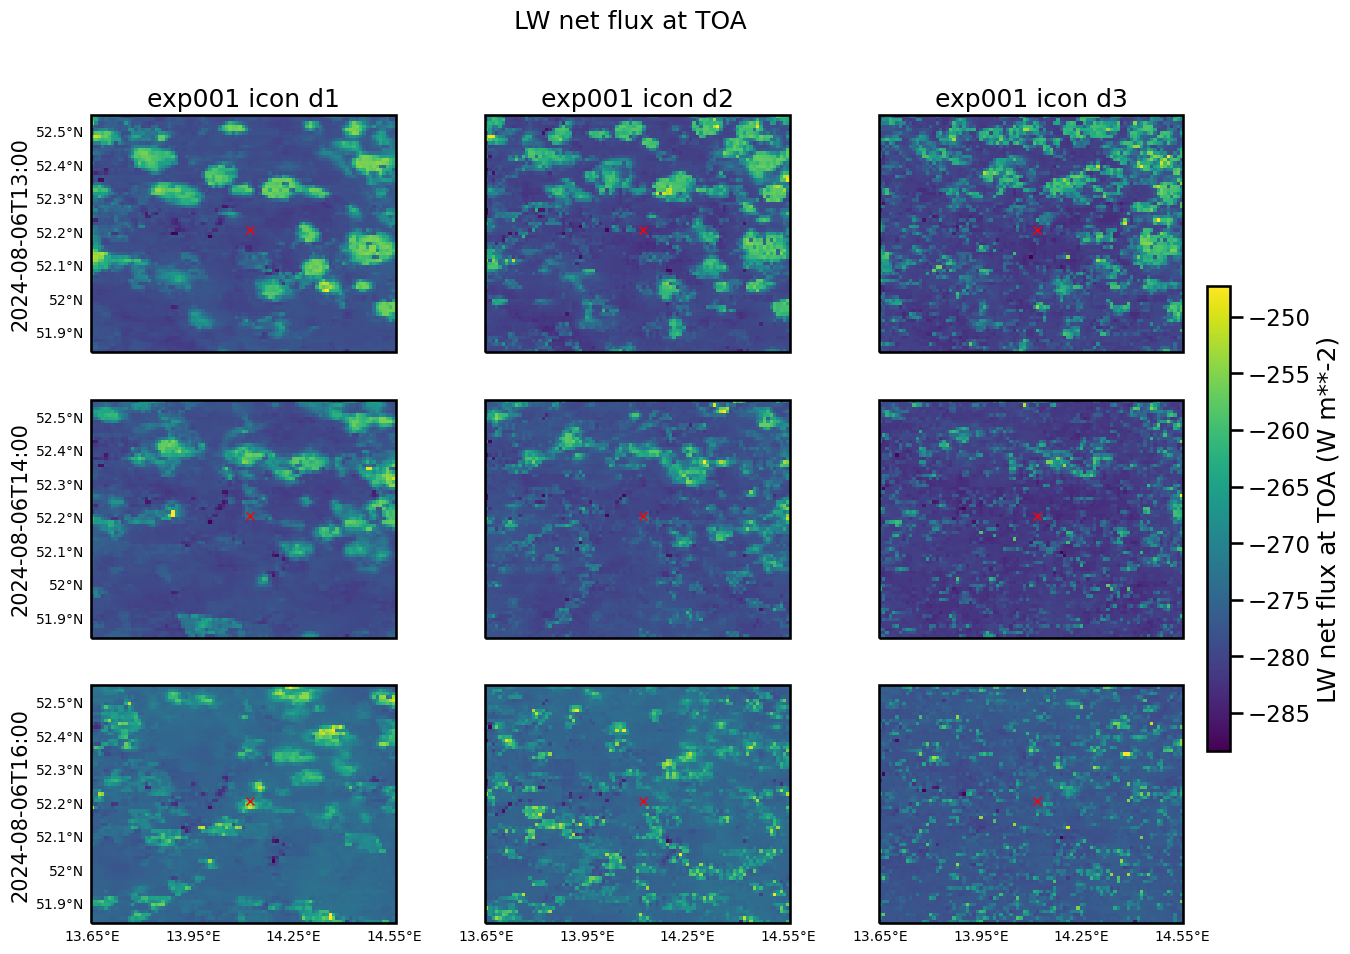

In [13]:
plot_map_multiple_times(datasets2d,'thb_t',time_points,"LW net flux at TOA","LW net flux at TOA (W m**-2)")

## Radiative variables surface

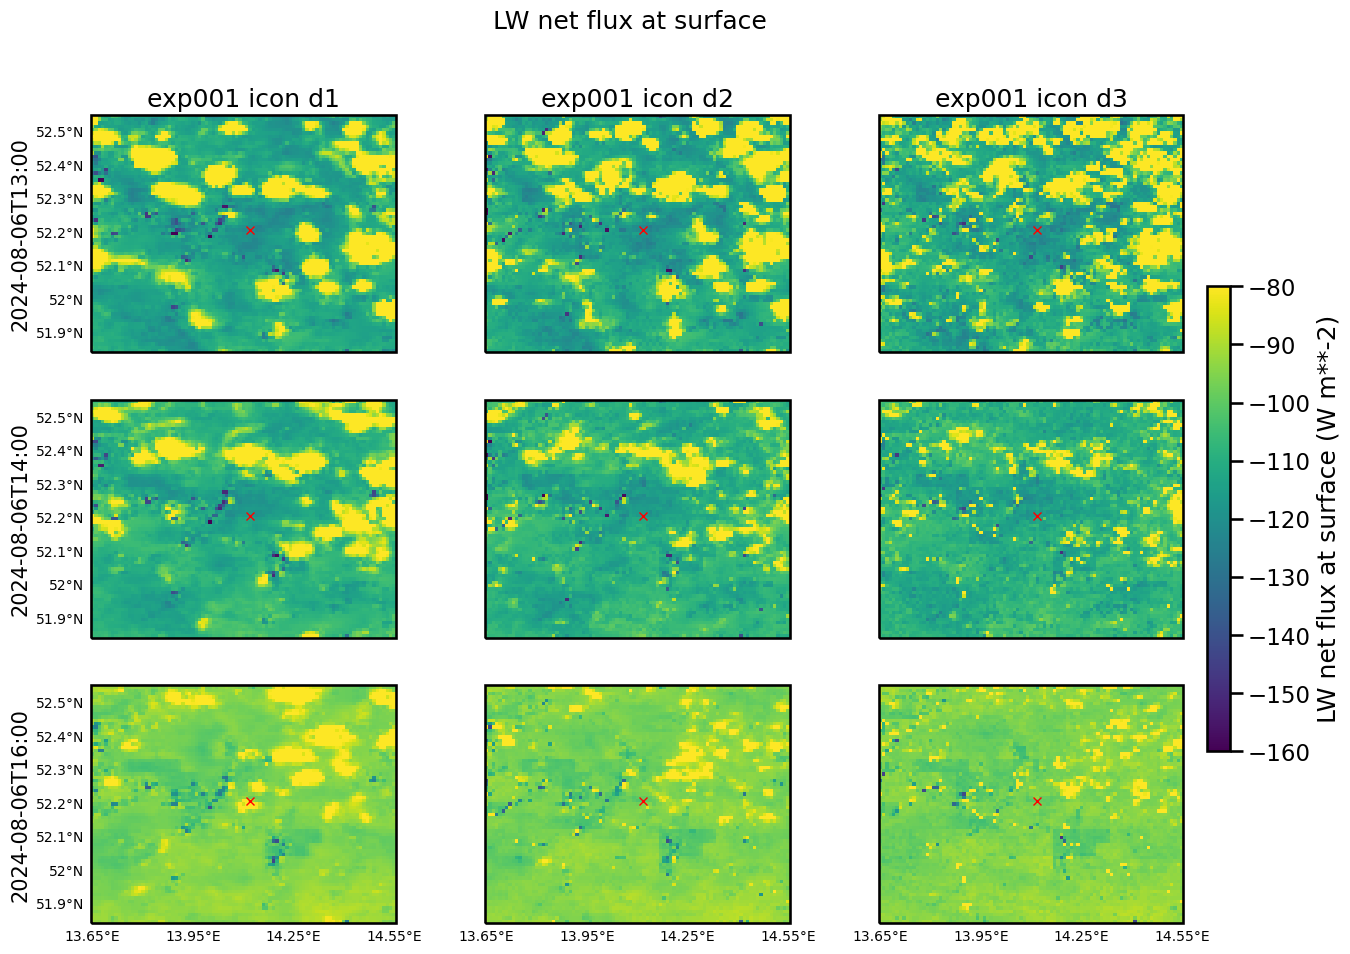

In [14]:
plot_map_multiple_times(datasets2d,'thb_s',time_points,"LW net flux at surface","LW net flux at surface (W m**-2)", vmin=-160, vmax=-80)

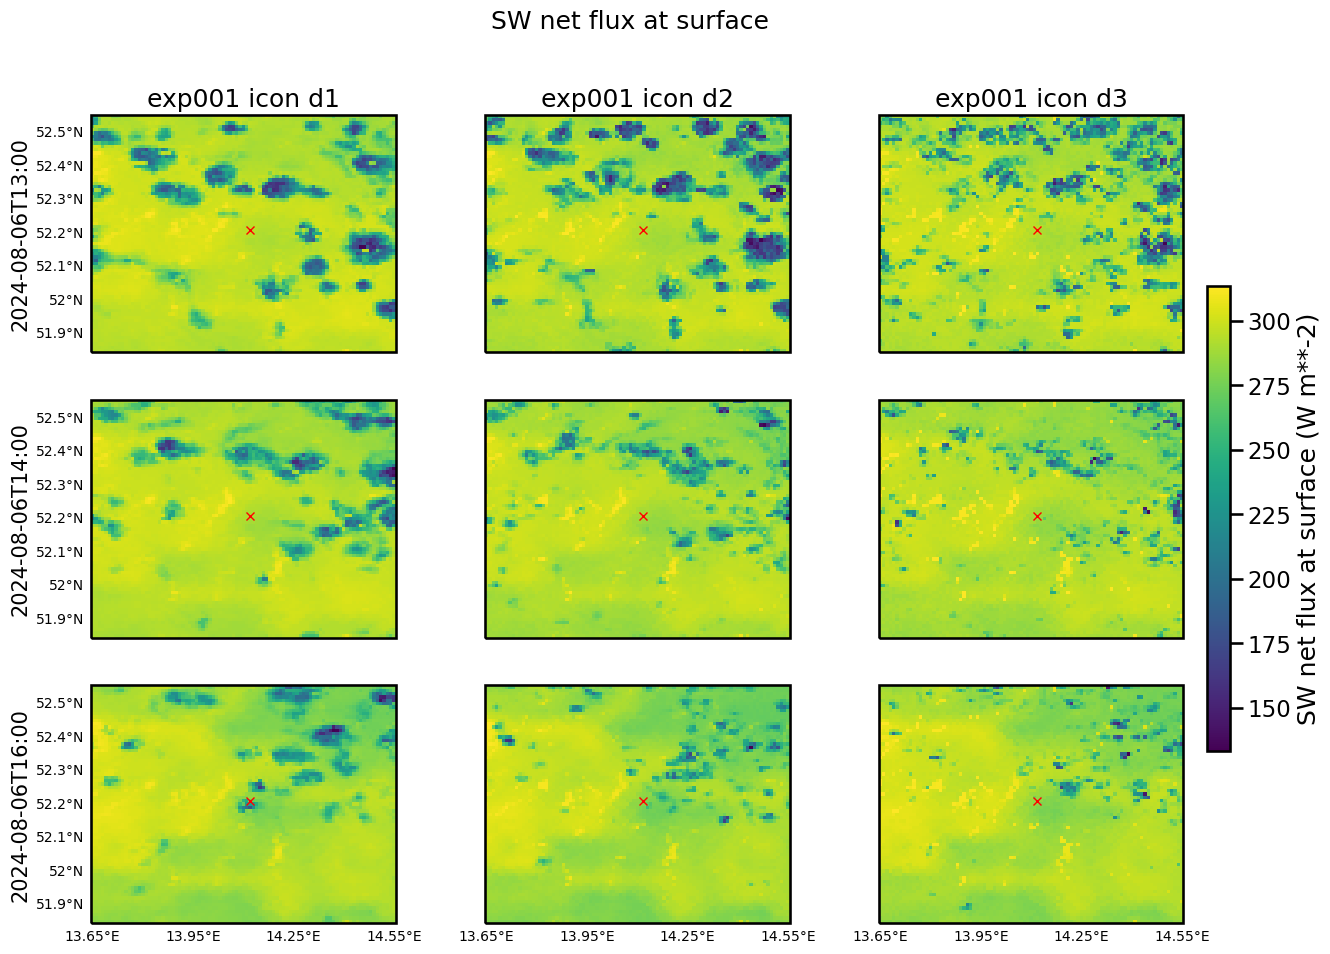

In [15]:
plot_map_multiple_times(datasets2d,'sob_s',time_points,"SW net flux at surface","SW net flux at surface (W m**-2)")

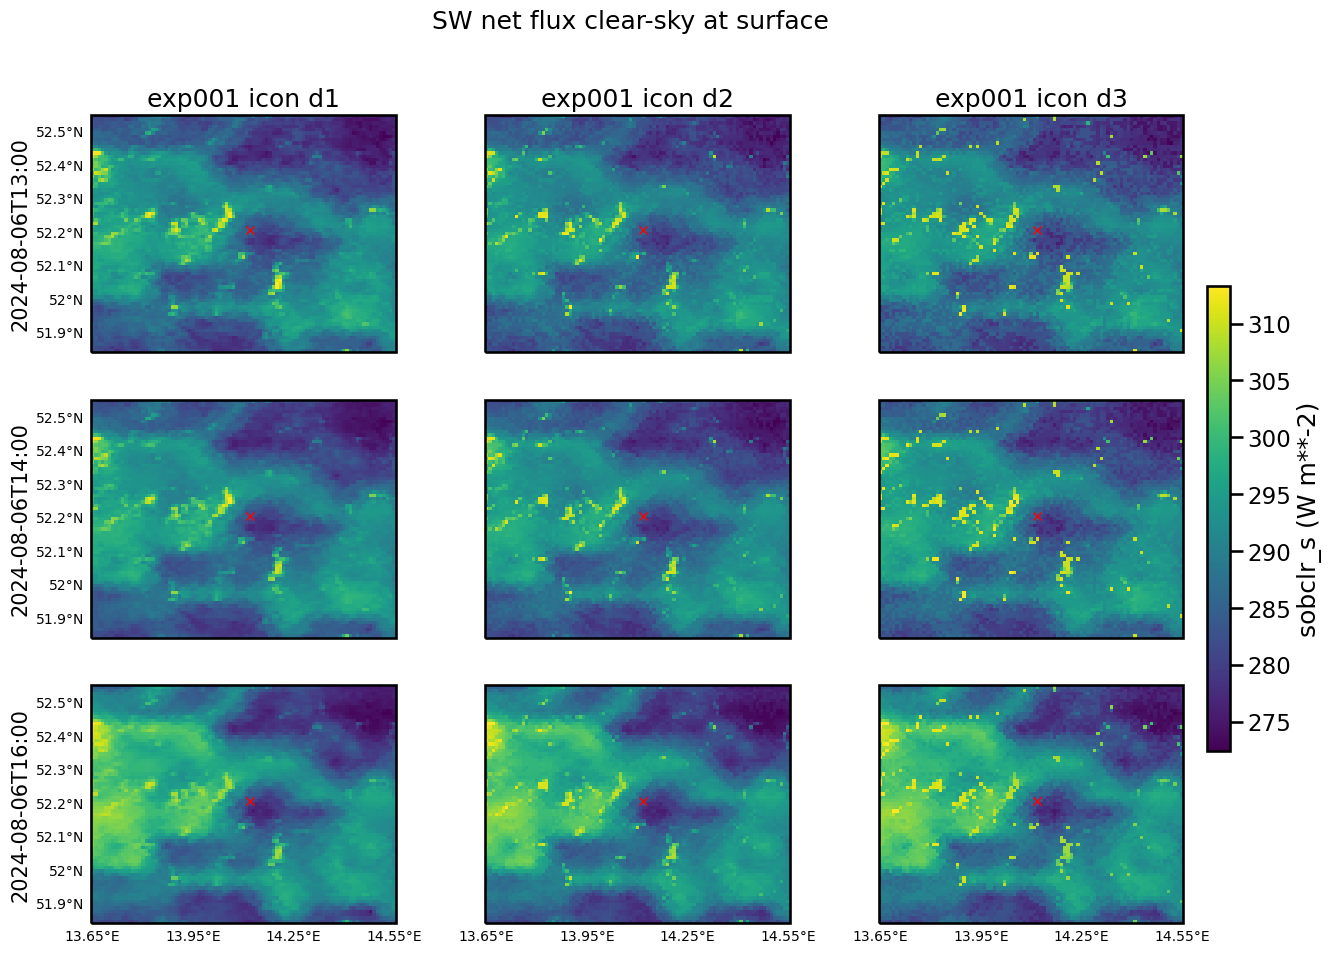

In [16]:
plot_map_multiple_times(datasets2d,'sobclr_s',time_points,"SW net flux clear-sky at surface","sobclr_s (W m**-2)")

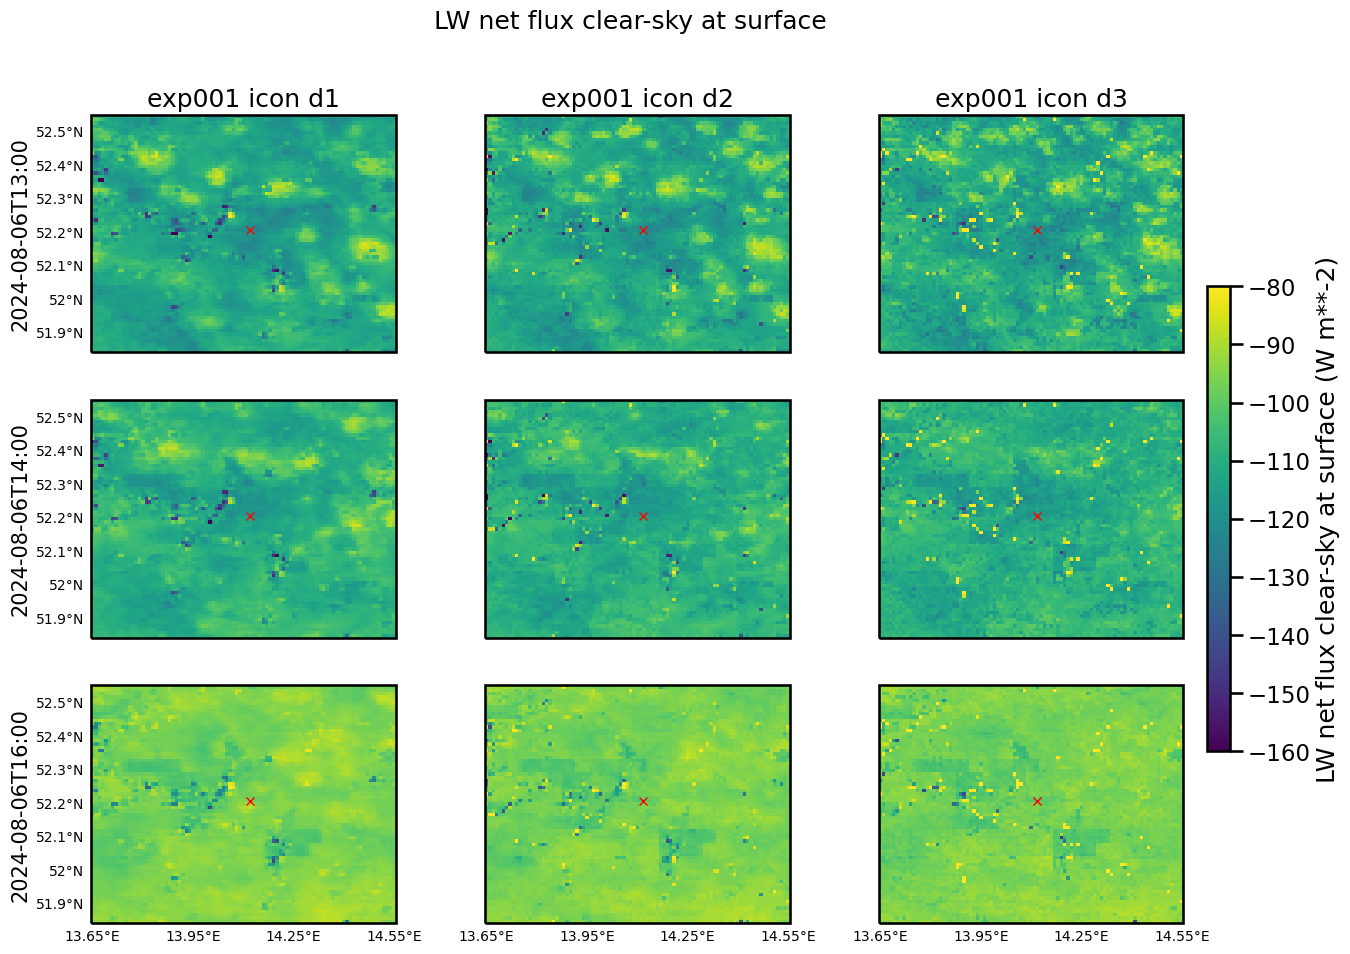

In [17]:
plot_map_multiple_times(datasets2d,'thbclr_s',time_points,"LW net flux clear-sky at surface","LW net flux clear-sky at surface (W m**-2)", vmin=-160, vmax=-80)

## Plot Liquid and ice water path

In [18]:
def plot_variable_mean(datasets, variable, title, mean_dims=('lat', 'lon')):
    """
    Plots the mean of a specified variable over given dimensions for multiple datasets.
    
    Parameters:
        datasets (dict): Dictionary where keys are dataset names and values are xarray datasets.
        variable (str): The name of the variable to plot.
        title (str): Title for the plot.
        mean_dims (tuple): Dimensions over which to compute the mean.
    """
    plt.figure(figsize=(10, 6))
    
    for name, ds in datasets.items():
        if variable in ds:
            var_mean = ds[variable].mean(dim=mean_dims)
            var_mean.plot(label=name)
        else:
            print(f"Warning: Variable '{variable}' not found in dataset '{name}'")
    
    plt.title(title)
    plt.legend()
    plt.show()

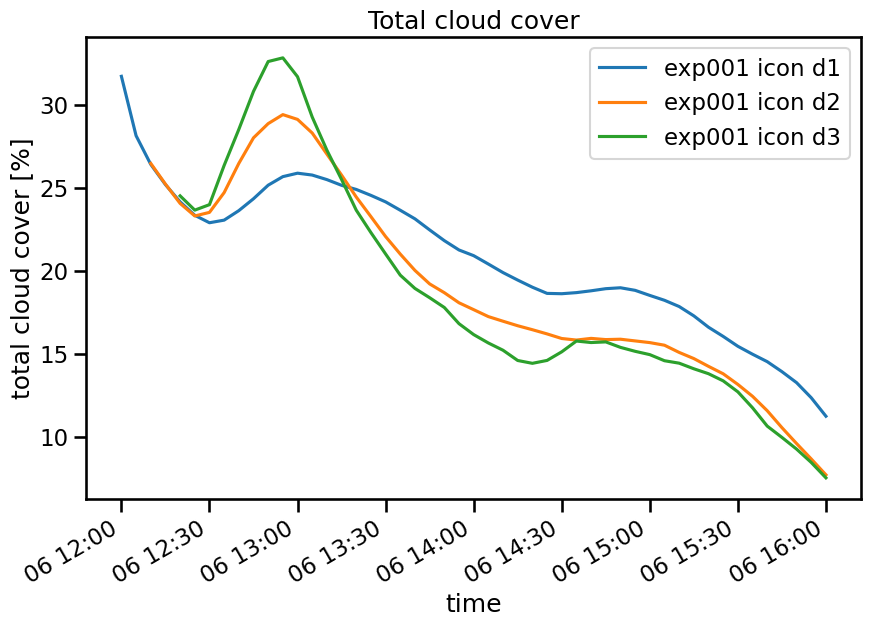

In [19]:
plot_variable_mean(datasets2d, 'clct', "Total cloud cover", mean_dims=('lat', 'lon'))

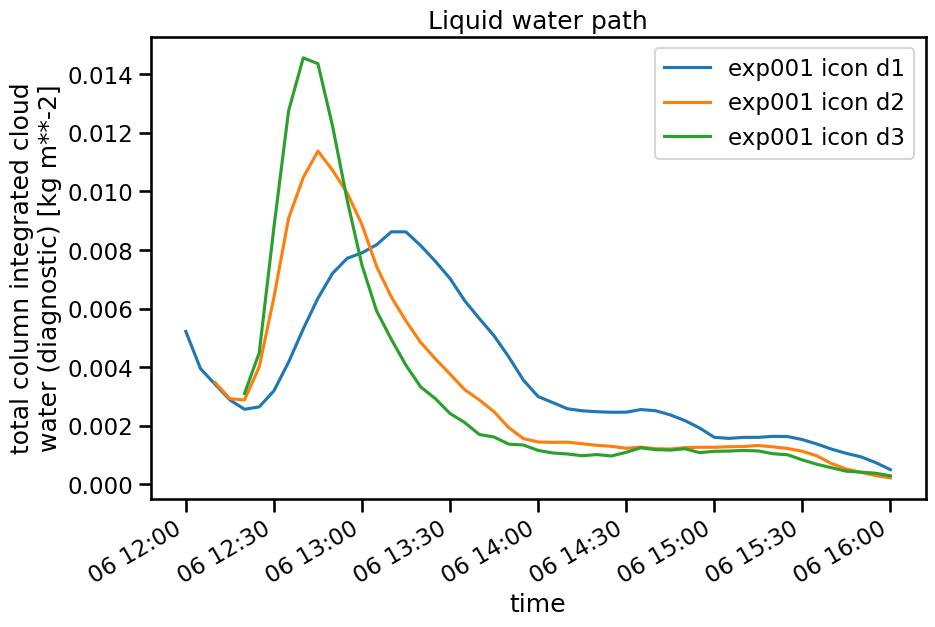

In [20]:
plot_variable_mean(datasets2d, 'tqc_dia', "Liquid water path", mean_dims=('lat', 'lon'))

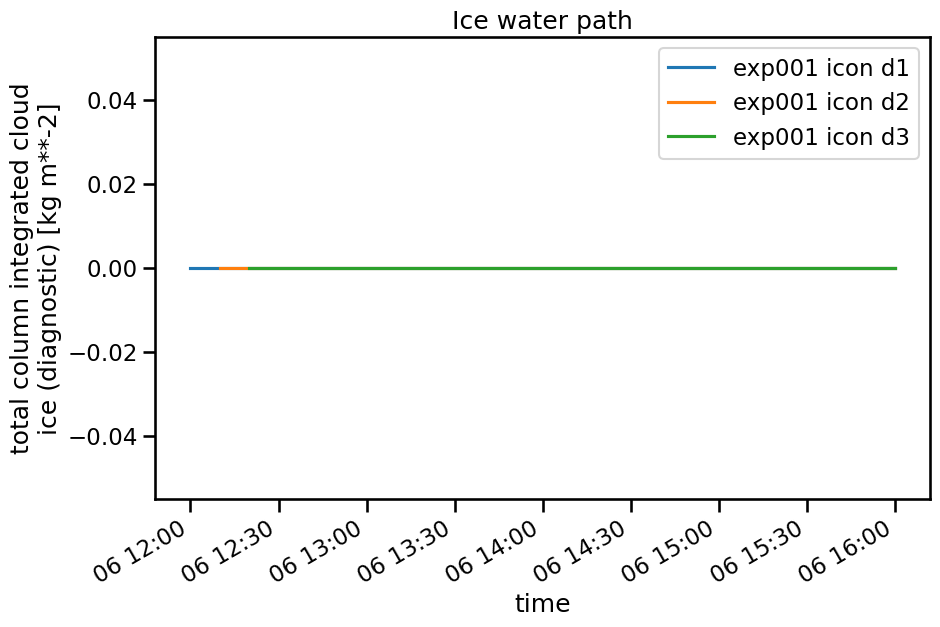

In [21]:
plot_variable_mean(datasets2d, 'tqi_dia', "Ice water path", mean_dims=('lat', 'lon'))

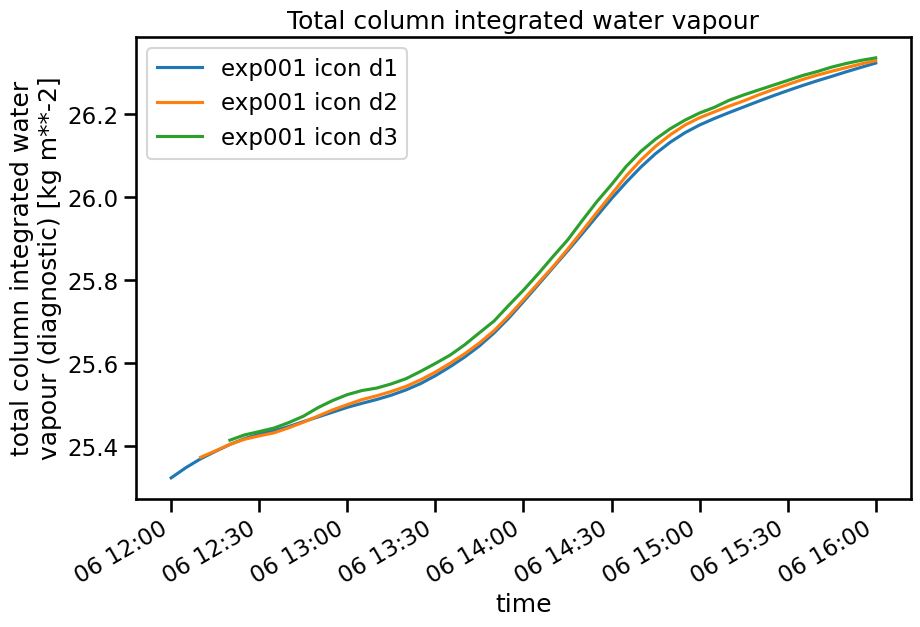

In [22]:
plot_variable_mean(datasets2d, 'tqv_dia', "Total column integrated water vapour", mean_dims=('lat', 'lon'))

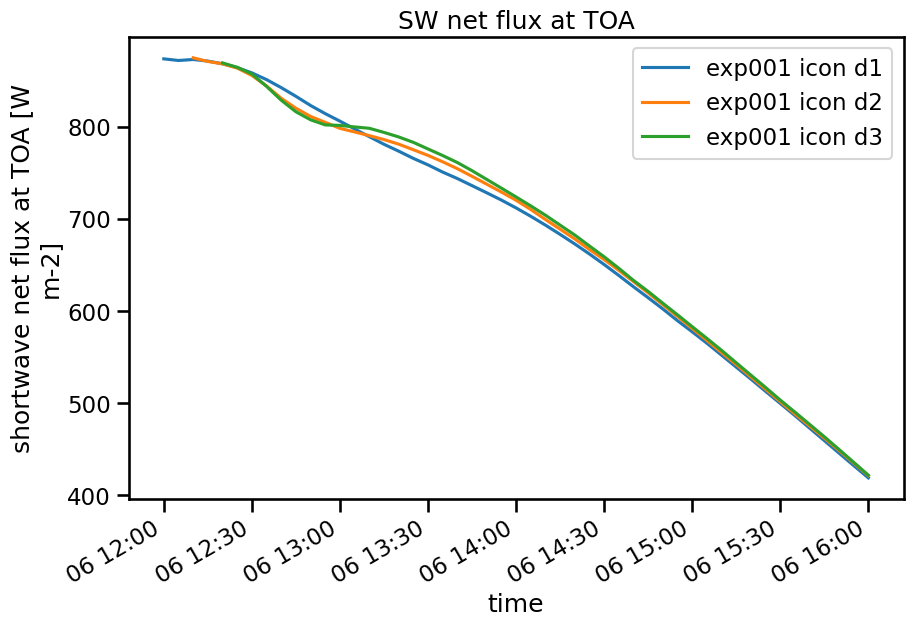

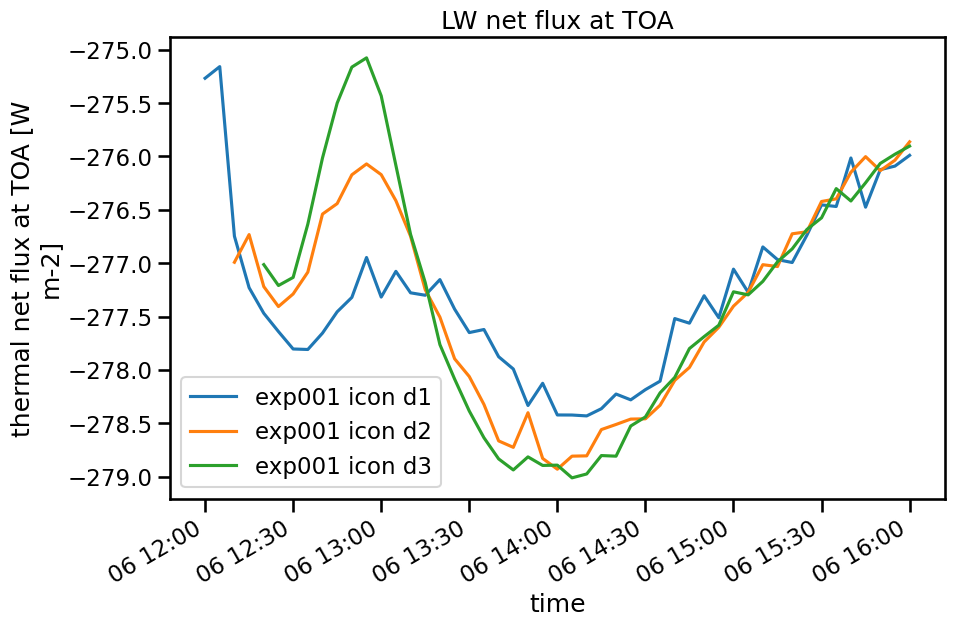

In [23]:
plot_variable_mean(datasets2d, 'sob_t', "SW net flux at TOA", mean_dims=('lat', 'lon'))
plot_variable_mean(datasets2d, 'thb_t', "LW net flux at TOA", mean_dims=('lat', 'lon'))

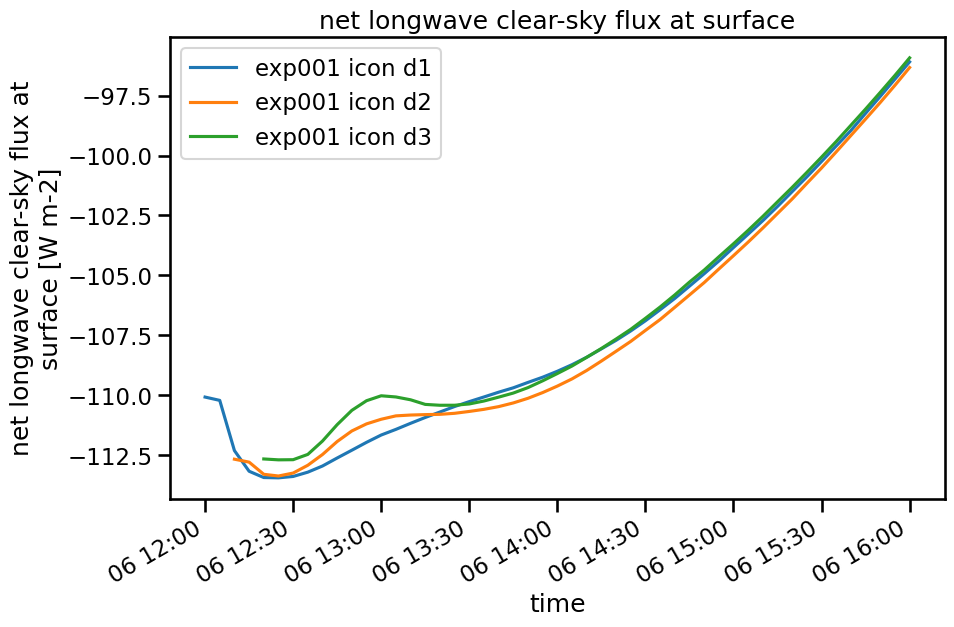

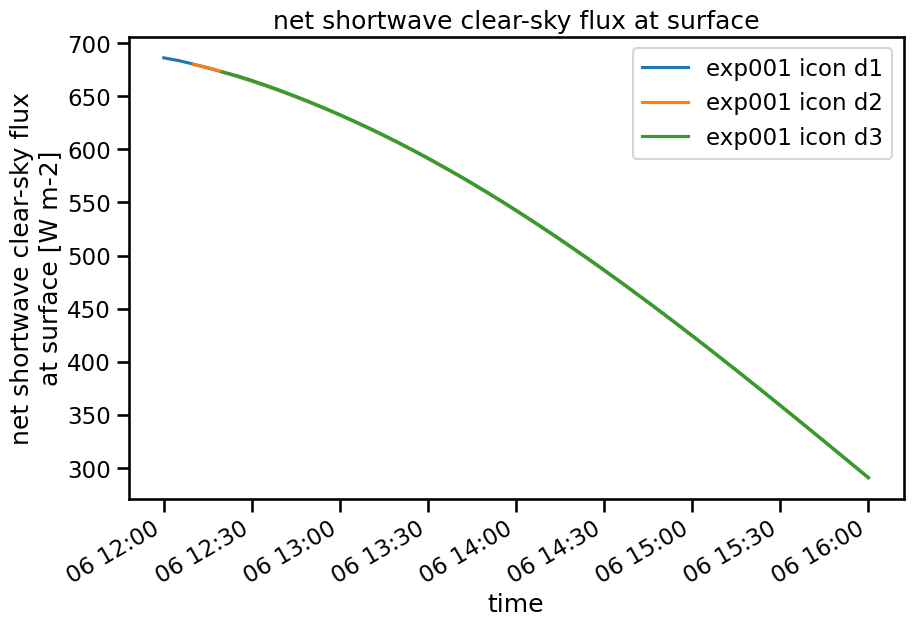

In [24]:
plot_variable_mean(datasets2d, 'thbclr_s', "net longwave clear-sky flux at surface", mean_dims=('lat', 'lon'))
plot_variable_mean(datasets2d, 'sobclr_s', "net shortwave clear-sky flux at surface", mean_dims=('lat', 'lon'))

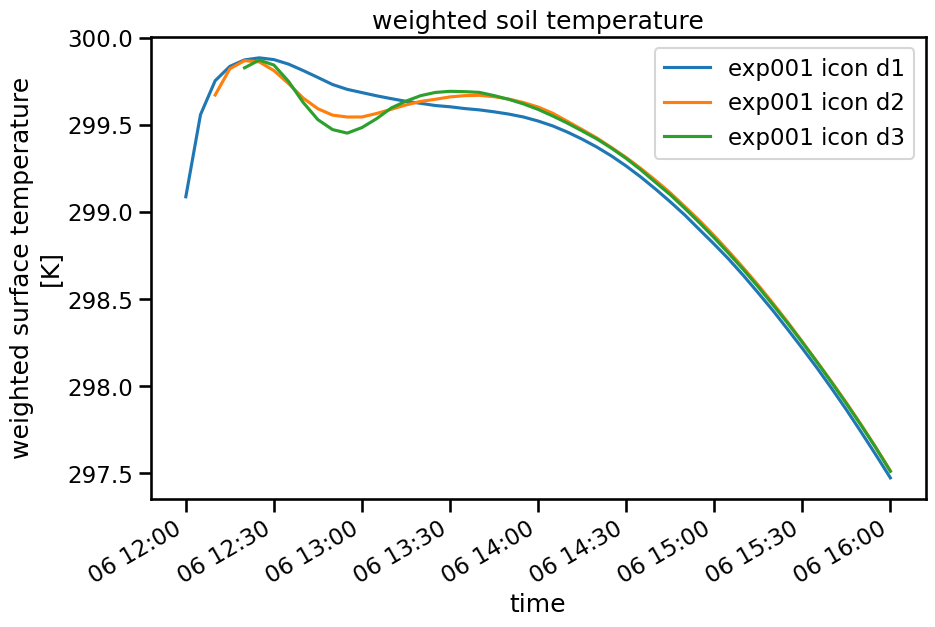

In [25]:
plot_variable_mean(datasets2d, 't_g', "weighted soil temperature", mean_dims=('lat', 'lon'))